# Dynamic Structure Factor Analysis

## Goal and physical setting

This notebook combines a variational state-preparation circuit, Trotterized real-time evolution, Hadamard-test measurements, and discrete Fourier transforms to construct a dynamic spin structure factor.

The spin Hamiltonian implemented by the helper class is

$$
H=-h\sum_i Z_i-J\sum_{\langle i,j\rangle}X_iX_j.
$$

The intended real-time correlation functions are

$$
C_{ij}^{mm}(t)=
\langle\psi_0|S_i^m(t)S_j^m(0)|\psi_0\rangle,
\qquad m\in\{X,Y,Z\},
$$

where $S_i^m(t)=U^\dagger(t)S_i^mU(t)$ and $U(t)=e^{-iHt}$. A spatial transform converts site indices into a momentum label, and a temporal transform converts the time dependence into a frequency spectrum.

### Workflow

1. Build a parameterized variational ansatz and estimate its energy with finite shots.
2. Select the best parameter from a one-dimensional grid scan.
3. Estimate complex two-time correlations with an ancilla-based Hadamard test.
4. Sum spin components and Fourier transform in space and time.
5. Plot time-domain signals and the magnitude of the frequency-domain result.

### Important interpretation

The calculated object is affected by ansatz error, finite-shot uncertainty, Trotter error, a finite time window, and discrete Fourier conventions. Each contribution must be distinguished before identifying spectral peaks with physical excitation energies.

In [2]:
# NumPy provides arrays, linear-algebra-friendly storage, and numerical grids.
import numpy as np
# Matplotlib visualizes the variational landscape and spectral data.
import matplotlib.pyplot as plt
# SciPy supplies the discrete temporal transform and its frequency bins.
from scipy.fft import ifft, fftfreq

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
def colorEdge(edges, e):
    """Color edges such that no two edges sharing a vertex have the same color.
    Args:
        edges: List of [vertex1, vertex2, color] for each edge
        e: Number of edges
    Returns:
        edges: Colored edge list
    Comment:
        coloring exposes potential parallelism in execution of 2-qubit gates, but does not itself guarantee a hardware schedule
        transpilation and backend constraints still matter
    """
    assert(e>0)
    # Add a third mutable field that will hold the color; -1 means unassigned.
    edge_list = [[q, r, -1] for (q, r) in edges]
    # Process one edge at a time and search for a nonconflicting integer color.
    i = 0
    color = 1
    while(i < e):
        edge_list[i][2] = color
        flag = False
        # Compare the candidate edge with every other edge for a shared endpoint.
        for j in range(e):
            if (j == i):
                continue
            if ((edge_list[i][0] == edge_list[j][0])or
                (edge_list[i][1] == edge_list[j][0]) or
                (edge_list[i][0] == edge_list[j][1]) or
                    (edge_list[i][1] == edge_list[j][1])):
                if (edge_list[i][2] == edge_list[j][2]):
                    # Retry this edge with the next candidate color.
                    color += 1
                    flag = True
                    break
        if (flag == True):
            continue
 
        color = 1
        i += 1
 
    # Scan the assigned labels to report the number of color classes.
    maxColor = -1
    for i in range(e):
        maxColor = max(maxColor, edge_list[i][2])
    print(str(maxColor)+" colors needed for edge coloring")
    for i in range(e):
        print("edge between v("+str(edge_list[i][0])+") and v("+ str(edge_list[i][1])+") has color "+str(edge_list[i][2]))

    return edge_list

In [4]:
class System:
  """
  Quantum system class for simulating spin-1/2 systems on graphs using Qiskit.
  
  This class manages VQE circuits, time evolution, and measurement protocols for
  computing quantum observables and correlations.
  """

  # Store model parameters and convert graph edges into scheduled color groups.
  def __init__(self,n=1,e=[],J=1.0,h=1.0,verbose=False):
    self.args = {}
    self.args['n_spin'] = n
    self.args['edges'] = e
    self.args['J'] = J
    self.args['h'] = h

    edges = self.args['edges']
    nedge = len(edges)
    edges = colorEdge(edges, nedge)
    # A set records the distinct interaction layers, but not an explicit order.
    color = set([edges[k][2] for k in range(nedge)])
    edges = {c:[(q,r) for (q,r,cqr) in edges if cqr==c] for c in color}
    if(verbose):
      for c in color: print("color ",c," edges ",edges[c])
    self.args['edges'] = edges
    self.args['color'] = color

  def prepare_bts(self,initial_bts=None,barrier=False):
    from qiskit import QuantumCircuit
    n = self.args['n_spin']
    qc = QuantumCircuit(n)
    if(initial_bts is not None):
       for i,xi in enumerate(initial_bts):
           if(xi==1): qc.x(i)
    if(barrier): qc.barrier()
    return qc

  def make_vqe_circuit(self,initial_bts=None,theta=0.0,barrier=False):
    """Build VQE ansatz circuit with parameterized RXY interactions.
    
    Args:
        initial_bts: Initial bit string (optional)
        theta: Variational parameter (rotation angle, not doubled)
        barrier: Add circuit barriers for visualization
    
    The RXY gate applies 2*theta as the full rotation angle.
    """
    def rxy(circuit, angle, a, b):
        """RXY(angle) = H_b CX_ba RY(angle)_a CX_ba H_b on qubits a, b."""
        circuit.h(b)
        circuit.cx(b, a)
        circuit.ry(angle, a)
        circuit.cx(b, a)
        circuit.h(b)
    from qiskit import QuantumCircuit
    color = self.args['color']
    edges = self.args['edges']
    n = self.args['n_spin']
    qc = self.prepare_bts(initial_bts,barrier)
    # Apply every colored interaction layer, in order
    for c in sorted(color):
        for q,r in edges[c]: rxy(qc, 2*theta, q, r)
    if(barrier): qc.barrier()
    return qc

  def make_vqe_measurement_circuits(self,initial_bts=None,theta=0.0,barrier=False):
    qc = self.make_vqe_circuit(initial_bts,theta,barrier)
    # measurement in Z basis
    qcz = qc.copy()
    # measurement in X basis
    qcx = qc.copy()
    for q in range(qcx.num_qubits): qcx.h(q)
    return [qcz,qcx]

  def make_time_evolution_circuit(self,dt=0.0,n_trotter=1,verbose=False,barrier=False):
    from qiskit import QuantumCircuit
    n = self.args['n_spin']
    h = self.args['h']
    J = self.args['J']
    qc = QuantumCircuit(n)
    color = self.args['color']
    edges = self.args['edges']
    # Repeat the symmetric field-half / interaction-full / field-half step.
    for i_trotter in range(n_trotter):
      # RZ(-h*dt) implements one half step generated by -h*Z.
      for q in range(n): qc.rz(-dt*h,q)
      if(barrier): qc.barrier()
      for c in color:
          # RXX(-2*J*dt) implements a full -J*X⊗X interaction step.
          for q,r in edges[c]: qc.rxx(-2*J*dt,q,r)
      if(barrier): qc.barrier()
      # RZ(-h*dt) implements one half step generated by -h*Z.
      for q in range(n): qc.rz(-dt*h,q)
      if(barrier): qc.barrier()
    return qc

  def measure_circuits_on_qasm(self,qc_dict,shots,verbose=False):
      from qiskit_aer import AerSimulator
      from qiskit.compiler import transpile
      simul = AerSimulator(method='matrix_product_state')
      qc_list = []
      for k in qc_dict.keys():
          qc = qc_dict[k]
          qc.measure_all()
          qc_list.append(transpile(qc, simul))
      results = simul.run(qc_list,shots=shots).result()
      counts = {}
      for j,k in enumerate(qc_dict.keys()):
          counts[k] = results.get_counts(j)
      return counts

  def measure_H_from_counts(self, counts_x, counts_z, verbose=False):
      e_ave = {}
      e_std = {}
      h = self.args['h']
      J = self.args['J']
      color = self.args['color']
      edges = self.args['edges']
      bases = ['z','x']
      results = {'z' : counts_z, 'x' : counts_x}
      for basis in bases:
          E1, E2 = 0.0, 0.0
          for k in results[basis].keys():
              # FIXED: Reverse bit string to match qubit ordering (LSB=qubit 0)
              v = results[basis][k]
              x = np.asarray([1-2*int(x) for x in k[::-1]])
              if(basis=='z'): Ex = sum(x)
              else:           Ex = sum([x[q]*x[r] for c in color for (q,r) in edges[c]])
              E1 += v*Ex
              E2 += v*(Ex**2)
          E1, E2 = E1/shots, E2/shots
          e_ave[basis] = E1
          # Estimate the standard error of the sampled energy contribution.
          e_std[basis] = np.sqrt(np.abs(E2-E1**2)/(shots-1))
          if(verbose): print(e_ave[basis],e_std[basis])
          if(verbose): print('-'*53)
      return -h*e_ave['z']-J*e_ave['x'], np.sqrt(h**2*e_std['z']**2+J**2*e_std['x']**2), e_ave, e_std

  def measure_single_qubit_operators(self, counts, verbose=False):
      Z1 = None
      Z2 = None
      for k in counts.keys():
          # FIXED: Reverse bit string to match qubit ordering (LSB=qubit 0)
          v = counts[k]
          if(Z1 is None):
              n = len(k)
              Z1 = np.zeros(n,dtype=float)
              Z2 = np.zeros(n,dtype=float)
          x = np.asarray([1-2*int(x) for x in k[::-1]])
          Z1 += v*x
          Z2 += v*x**2
      Z1, Z2 = Z1/shots, Z2/shots
      Z2 = np.sqrt(np.abs(Z2-Z1**2)/(shots-1))
      return Z1, Z2

## Part 1 — Set Up the Three-Spin System

The example is an open chain with three spins and nearest-neighbor edges $(0,1)$ and $(1,2)$. Both coupling strengths are set to one. With $\hbar=1$, the dimensionless parameters controlling the dynamics are $Jt$ and $ht$.

The `System` constructor assigns interaction edges to color classes. Edges of the same color share no qubit and can therefore be placed in the same ideal circuit layer. For this three-site open chain, the two edges require two colors.

The boundary condition matters later: ordinary lattice momenta $2\pi q/N$ are natural for a periodic, translation-invariant chain, whereas this system is open and not exactly translation invariant.

In [5]:
# Use a small open chain that can also be benchmarked by exact diagonalization.
n = 3
# Nearest-neighbor edges; there is no periodic (2,0) bond.
e = [(0,1),(1,2)]
J = 1.0
h = 1.0
# Construct the model and its colored edge schedule.
S = System(n,e,J,h)

2 colors needed for edge coloring
edge between v(0) and v(1) has color 1
edge between v(1) and v(2) has color 2


## Part 2 — Variational Energy Scan

The variational quantum eigensolver (VQE) searches for a low-energy state within a parameterized circuit family. Here the search is a uniform scan over a single shared parameter $\theta$ rather than a general-purpose classical optimizer.

For every grid point, the energy estimator combines

$$
\langle H\rangle
=-h\sum_i\langle Z_i\rangle
-J\sum_{\langle i,j\rangle}\langle X_iX_j\rangle.
$$

The $Z$ terms are sampled in the computational basis. Applying Hadamard gates before measurement rotates the $X$ basis into the computational basis, allowing all $XX$ edge terms to be estimated from the same set of bit strings.

The error bars describe finite-shot uncertainty at a fixed parameter. They do not include ansatz bias, grid discretization error, or the statistical bias introduced by selecting the smallest value among many noisy estimates.

In [6]:
# Each Hamiltonian basis is estimated from this many sampled outcomes.
shots = 500
ang_vec = []
ave_vec = []
std_vec = []

# Scan over VQE parameter theta
# Uniformly scan 41 parameter values, including both endpoints.
theta_array = np.arange(-np.pi,np.pi+1e-4,np.pi/20.0)
qc_dict = {}
for i,theta in enumerate(theta_array):
    qcz, qcx = S.make_vqe_measurement_circuits(theta=theta)
    qc_dict['%d_z'%i] = qcz
    qc_dict['%d_x'%i] = qcx

counts_dict = S.measure_circuits_on_qasm(qc_dict, shots)

for i,theta in enumerate(theta_array):
    # Combine sampled Z-field and XX-interaction contributions.
    e_ave, e_std, _, _ = S.measure_H_from_counts(counts_dict['%d_x'%i], counts_dict['%d_z'%i])
    ang_vec.append(theta)
    ave_vec.append(e_ave)
    std_vec.append(e_std)
    print("theta=%.16f E=%.16f +/- %.16f "%(theta, e_ave, e_std))

theta=-3.1415926535897931 E=-2.9520000000000000 +/- 0.0630185263977085 
theta=-2.9845130209103035 E=-3.3919999999999999 +/- 0.0672529994265217 
theta=-2.8274333882308138 E=-3.1680000000000001 +/- 0.0843065310777565 
theta=-2.6703537555513241 E=-2.5080000000000000 +/- 0.0983915534768670 
theta=-2.5132741228718345 E=-1.2240000000000000 +/- 0.1043551819892814 
theta=-2.3561944901923448 E=0.0480000000000000 +/- 0.0981528806299229 
theta=-2.1991148575128552 E=1.0240000000000000 +/- 0.0811942918317052 
theta=-2.0420352248333655 E=1.7240000000000002 +/- 0.0609227639420001 
theta=-1.8849555921538759 E=1.9119999999999999 +/- 0.0494322069725027 
theta=-1.7278759594743862 E=1.6080000000000001 +/- 0.0582706008708654 
theta=-1.5707963267948966 E=0.9040000000000000 +/- 0.0621392837194180 
theta=-1.4137166941154069 E=0.3720000000000000 +/- 0.0570401539121051 
theta=-1.2566370614359172 E=0.0160000000000000 +/- 0.0488304908194392 
theta=-1.0995574287564276 E=-0.1240000000000000 +/- 0.0592849847671202 


## Part 3 — Inspect the VQE Energy Landscape

The energy curve reveals the parameter region favored by this one-parameter ansatz. The notebook chooses the sampled grid point with the lowest estimated energy and reuses that angle for the real-time calculation.

Because the scan is discrete, the selected angle need not coincide with the continuous optimum. Moreover, the minimum of noisy estimates tends to be biased downward relative to the underlying expectation values ("winner's curse"). A robust workflow would refine the grid near the minimum and reevaluate the finalists with more shots or an exact simulator.

For a valid variational calculation, the exact expectation value of any normalized trial state must satisfy $\langle H\rangle\ge E_0$. Individual finite-shot estimates can fluctuate below their exact trial-state energies, so the variational bound applies to exact expectations rather than every sampled number.

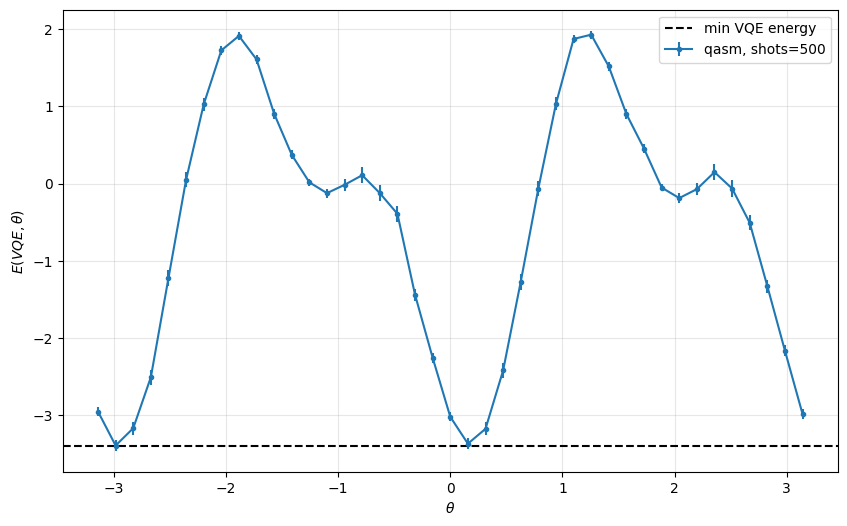

Optimal angle  -2.9845130209103035


In [7]:
plt.figure(figsize=(10, 6))
# Display the sampled energy and its estimated standard error at each grid point.
plt.errorbar(ang_vec, ave_vec, yerr=std_vec, marker='.', label='qasm, shots=%d'%shots)
plt.axhline(min(ave_vec),color='k',ls='--',label='min VQE energy')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$E(VQE,\theta)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Select the lowest finite-shot grid estimate for subsequent state preparation.
theta = ang_vec[np.argmin(ave_vec)]
print("Optimal angle ",theta)

## Part 4 — Measure Two-Time Spin Correlations

The Hadamard-test circuit creates two coherent system branches,

$$
|a\rangle=U(t)|\psi_0\rangle,
\qquad
|b\rangle=S_i^mU(t)S_j^m|\psi_0\rangle.
$$

Ancilla interference gives

$$
\langle a|b\rangle
=\langle\psi_0|U^\dagger(t)S_i^mU(t)S_j^m|\psi_0\rangle
=C_{ij}^{mm}(t).
$$

A final Hadamard on the ancilla estimates the real part. Applying $S^\dagger$ and then a Hadamard estimates the imaginary part. The explicit $U^\dagger$ is supplied automatically by the bra branch of the overlap and does not appear as a separate circuit block.

The result array has axes `[i, j, Pauli component, real/imaginary, time]`. Correctly locating the ancilla in the returned count strings is essential: Qiskit displays classical bit strings most-significant bit first, while qubit indices increase from the least-significant end.

In [8]:
def make_hadamard_circuit(psi, qct, op1, op2, q1, q2):
    """Create Hadamard test circuits for measuring correlation functions.
    
    Args:
        psi: Preparation circuit (system qubits only)
        qct: Time-evolution circuit U(t) (system qubits only)
        op1: Operator at time 0 (system qubit q1) - 'X', 'Y', or 'Z'
        op2: Operator at time t (system qubit q2) - 'X', 'Y', or 'Z'
        q1: System qubit index for first operator
        q2: System qubit index for second operator
    
    Returns:
        qcx: Circuit measuring real part of <ψ|U†(t) op2 U(t) op1|ψ>
        qcy: Circuit measuring imaginary part
        ancilla: Index of the ancilla qubit in the returned circuits
    
    The measured correlator is C_ij^mm(t) = <ψ_0|U†(t) S_j^m(t) U(t) S_i^m(0)|ψ_0>
    """
    from qiskit import QuantumCircuit
    if(op1!='X' and op1!='Y' and op1!='Z'): exit()
    if(op2!='X' and op2!='Y' and op2!='Z'): exit()
    if(q1<0 or q1>psi.num_qubits-1): exit()
    if(q2<0 or q2>psi.num_qubits-1): exit()
    if(psi.num_qubits!=qct.num_qubits): exit()

    N = psi.num_qubits
    qc = QuantumCircuit(N + 1)
    # Append the ancilla after all N system qubits.
    ancilla = N
    qc = qc.compose(psi, [x for x in range(N + 1) if x != ancilla])
    qc.barrier()
    # Create two coherent branches whose overlap encodes the correlator.
    qc.h(ancilla)
    qc.barrier()
    if(op1 == 'X'):
        qc.cx(ancilla, q1)
    if(op1 == 'Y'):
        qc.cy(ancilla, q1)
    if(op1 == 'Z'):
        qc.cz(ancilla, q1)
    qc.barrier()
    # Apply U(t) only to the system register; the ancilla is excluded.
    qc = qc.compose(qct, [x for x in range(N + 1) if x != ancilla])
    qc.barrier()
    if(op2 == 'X'):
        qc.cx(ancilla, q2)
    if(op2 == 'Y'):
        qc.cy(ancilla, q2)
    if(op2 == 'Z'):
        qc.cz(ancilla, q2)
    qc.barrier()
    qcx = qc.copy()
    # Final H measures the ancilla X expectation, yielding the real part.
    qcx.h(ancilla)
    qcy = qc.copy()
    # S† and H map the ancilla Y expectation, yielding the imaginary part.
    qcy.sdg(ancilla)
    qcy.h(ancilla)
    return qcx, qcy, ancilla

In [9]:
tmax = 16.0
dt = 0.2
# Requested times cover 0 <= t < tmax with spacing dt.
# Use integer step indices to avoid floating-point rounding issues.
n_steps_max = int(tmax / dt)
t_vec = np.arange(n_steps_max) * dt
# constant number of Trotter steps, to contain circuit size/depth
n_trotter = 8
# Correlations use fewer shots than the VQE scan, increasing sampling uncertainty.
shots = 500

# Initialize arrays to store correlations
# Dimensions: [spin_i, spin_j, Pauli_basis(X,Y,Z), Real/Imag, time]
# C[i,j,m,0,t] = real part of <S_i^m(t)S_j^m(0)>
# C[i,j,m,1,t] = imag part of <S_i^m(t)S_j^m(0)>
# Axis order: site i, site j, Pauli component, Re/Im, time index.
Spin_Spin_Correlation_Ave = np.zeros((n,n,3,2,len(t_vec)))
Spin_Spin_Correlation_Std = np.zeros((n,n,3,2,len(t_vec)))

print(f"Computing correlations for {len(t_vec)} time points...")

Computing correlations for 80 time points...


In [21]:
# Main computation loop: measure all correlations
# Measure the three diagonal spin-component channels XX, YY, and ZZ.

qc_dict = {}

for m,basis in enumerate(['X','Y','Z']):
    for i in range(n):
        for j in range(n):
            for k,t in enumerate(t_vec):
                qc0 = S.make_vqe_circuit(theta=theta)
                # Convert each requested time to a whole Trotter-step count.
                qct = S.make_time_evolution_circuit(dt=dt,n_trotter=k) #dt=t/n_trotter,n_trotter=n_trotter)
                # Build separate ancilla-readout circuits for the real/imaginary parts.
                qcx, qcy, ancilla = make_hadamard_circuit(qc0,qct,basis,basis,i,j)
                qc_dict['qubits_%d_%d_time_%d_pauli_%s_re'%(i,j,k,basis)] = qcx
                qc_dict['qubits_%d_%d_time_%d_pauli_%s_im'%(i,j,k,basis)] = qcy

print("Circuits prepared")
counts_dict = S.measure_circuits_on_qasm(qc_dict, shots)
print("Circuits measured")

Circuits prepared
Circuits measured


In [22]:
ancilla = S.args['n_spin'] # last qubit

for m,basis in enumerate(['X','Y','Z']):
    for i in range(n):
        for j in range(n):
            for k,t in enumerate(t_vec):
                # qcx measures real part (final Hadamard)
                counts = counts_dict['qubits_%d_%d_time_%d_pauli_%s_re'%(i,j,k,basis)]
                R_ave, R_std = S.measure_single_qubit_operators(counts)
                Spin_Spin_Correlation_Ave[i,j,m,0,k] = R_ave[ancilla]
                Spin_Spin_Correlation_Std[i,j,m,0,k] = R_std[ancilla]
                counts = counts_dict['qubits_%d_%d_time_%d_pauli_%s_im'%(i,j,k,basis)]
                I_ave, I_std = S.measure_single_qubit_operators(counts)
                Spin_Spin_Correlation_Ave[i,j,m,1,k] = I_ave[ancilla]
                Spin_Spin_Correlation_Std[i,j,m,1,k] = I_std[ancilla]
    print(f"  {basis} basis complete")

  X basis complete
  Y basis complete
  Z basis complete


## Part 5 — Spatial Fourier Transform

The notebook aims to construct

$$
S(q,t)=\sum_{i,j}e^{iq(i-j)}
\sum_{m\in\{X,Y,Z\}}C_{ij}^{mm}(t),
$$

followed by a temporal transform

$$
S(q,\omega)=\int dt\,e^{+i\omega t}S(q,t).
$$

Summing $X$, $Y$, and $Z$ produces a spin-component-summed structure factor. Whether a factor such as $1/N$ is included is a normalization convention, but it must be stated when comparing amplitudes with theory or other software.

For a periodic translation-invariant chain, momenta $q_k=2\pi k/N$ are natural. This notebook applies those phases to an open three-site chain, so the result is best viewed as a discrete spatial Fourier diagnostic rather than an exact decomposition into momentum eigenmodes. Open-boundary normal modes are commonly represented with sine-wave momenta.

The uncertainty propagation assumes statistically independent estimates. Phase factors mix real and imaginary components, so the uncertainty of a particular plotted component should be propagated through the same complex linear transformation used for the signal.

In [23]:
n_momenta = n
# Allocate a complex time-domain signal [re and im parts]
# and its statistical uncertainty [re and im parts]
DSF_ave = np.zeros((n_momenta,2,len(t_vec)))
DSF_std = np.zeros((n_momenta,2,len(t_vec)))
# number of resampling to evaluate standard deviations
resample = 50

# FIXED: Restructured loop to accumulate DSF for all (i,j) pairs per momentum q,
# before normalization. This ensures each momentum mode shows distinct structure.

for q in range(n_momenta):
    for k,t in enumerate(t_vec):

        DSF_accum_re  = 0.0
        DSF_accum_im  = 0.0
        DSF_accum_re2 = 0.0
        DSF_accum_im2 = 0.0

        for r in range(resample):      
            DSF_re_r = 0.0
            DSF_im_r = 0.0
            for i in range(n):
                for j in range(n):
                    for m,basis in enumerate(['X','Y','Z']):
                        # Combine real and imaginary parts into complex correlation
                        # Sum over all Pauli bases (X, Y, Z) to get total correlation
                        # Apply the periodic-chain discrete spatial phase for momentum index q.
                        phase_factor = np.exp(1j*(i-j)*2.0*np.pi*q/n)
                        # Reconstruct each Pauli-channel correlation from its sampled components.
                        re = np.random.normal(Spin_Spin_Correlation_Ave[i,j,m,0,k], Spin_Spin_Correlation_Std[i,j,m,0,k])
                        im = np.random.normal(Spin_Spin_Correlation_Ave[i,j,m,1,k], Spin_Spin_Correlation_Std[i,j,m,1,k])
                        fn = phase_factor * (re+1j*im)
                        # Sum X, Y, and Z channels and accumulate every ordered site pair.
                        DSF_re_r += np.real(fn)
                        DSF_im_r += np.imag(fn)

            DSF_accum_re += DSF_re_r
            DSF_accum_im += DSF_im_r
            DSF_accum_re2 += DSF_re_r**2
            DSF_accum_im2 += DSF_im_r**2

        DSF_ave[q,0,k] = DSF_accum_re / resample
        DSF_ave[q,1,k] = DSF_accum_im / resample
        DSF_std[q,0,k] = np.sqrt(np.abs(DSF_accum_re2/resample - (DSF_accum_re/resample)**2))
        DSF_std[q,1,k] = np.sqrt(np.abs(DSF_accum_im2/resample - (DSF_accum_im/resample)**2))

print("Spatial Fourier transform complete")

Spatial Fourier transform complete


## Part 6 — Temporal Fourier Transform

The discrete transform maps $N_t$ equally spaced samples separated by $\Delta t$ into frequency bins

$$
f_k=\frac{k}{N_t\Delta t},
\qquad
\omega_k=2\pi f_k.
$$

The total sampled duration controls the frequency spacing, while the sampling interval controls the Nyquist limit. A finite one-sided time record also broadens sharp spectral lines and creates leakage between bins. Window functions, longer evolution times, or model-based spectral reconstruction can reduce or characterize these effects.

Transform sign and normalization conventions are crucial. SciPy's `ifft` uses an $e^{+i\omega t}$ kernel (as specified in the equation above). For a complex quantum correlation function, the `ifft` gives the correct spectral decomposition.

In [28]:
# Frequencies are in cycles per unit time; multiply by 2π for angular frequency.
# Retain strictly positive forward-FFT bins
freqs = fftfreq(len(t_vec), dt)
pos_freq_idx = freqs > 0
n_pos_freqs = np.sum(pos_freq_idx)

DSF_fft_ave = np.zeros((n_momenta, n_pos_freqs), dtype=float)
DSF_fft_std = np.zeros((n_momenta, n_pos_freqs), dtype=float)

for q in range(n_momenta):
    # Apply IFFT to convert time-domain DSF to frequency domain
    # SciPy's ifft uses an exp(+i*omega*t) kernel, matching the equation definition.
    DSF_fft_accum = np.zeros(n_pos_freqs, dtype=float)
    DSF_fft_accum2 = np.zeros(n_pos_freqs, dtype=float)
    
    for r in range(resample):
        re = np.asarray([np.random.normal(DSF_ave[q, 0, k], DSF_std[q, 0, k]) for k in range(len(t_vec))])
        im = np.asarray([np.random.normal(DSF_ave[q, 1, k], DSF_std[q, 1, k]) for k in range(len(t_vec))])
        cp = re+1j*im
        fft_vals = ifft(cp)[pos_freq_idx]
        fft_real = np.abs(fft_vals)
        DSF_fft_accum += fft_real
        DSF_fft_accum2 += fft_real**2
    
    DSF_fft_ave[q, :] = DSF_fft_accum / resample
    DSF_fft_std[q, :] = np.sqrt(np.abs(DSF_fft_accum2/resample - (DSF_fft_accum/resample)**2))

print("Temporal FFT and error propagation complete")

Temporal FFT and error propagation complete


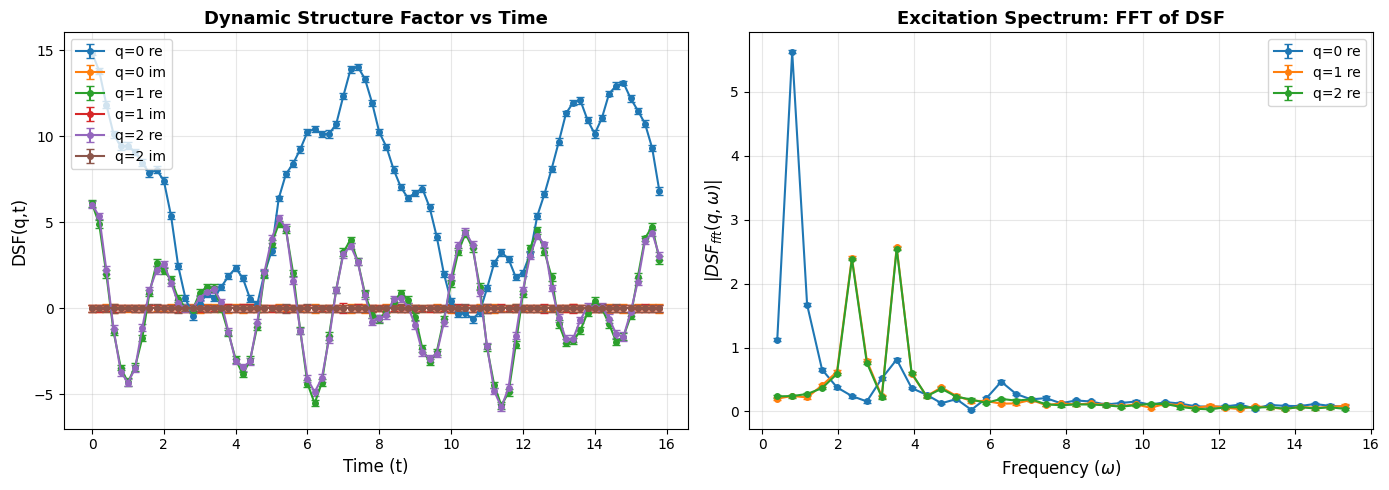


Analysis complete! The frequency peaks indicate characteristic excitation energies of the system.


In [29]:
# Create comprehensive visualization of DSF results
# Compare the spatially transformed time trace with its temporal spectrum.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels = [f'q={q}' for q in range(n_momenta)]

# LEFT PLOT: DSF vs time (time-domain view)
for q in range(n_momenta):
    axes[0].errorbar(t_vec, DSF_ave[q, 0, :].real, yerr=DSF_std[q, 0, :],
                     marker='o', linestyle='-', label=labels[q]+' re', markersize=4, capsize=3)
    axes[0].errorbar(t_vec, DSF_ave[q, 1, :].imag, yerr=DSF_std[q, 1, :],
                     marker='o', linestyle='-', label=labels[q]+' im', markersize=4, capsize=3)

axes[0].set_xlabel('Time (t)', fontsize=12)
axes[0].set_ylabel('DSF(q,t)', fontsize=12)
axes[0].set_title('Dynamic Structure Factor vs Time', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# RIGHT PLOT: FFT of DSF (frequency-domain view)
for q in range(n_momenta):
    freqs = fftfreq(len(t_vec), dt)
    pos_freq_idx = freqs > 0
    # Convert cycles/time into angular frequency.
    omega = 2 * np.pi * freqs[pos_freq_idx]

    # Plot spectral magnitude; nonlinear magnitude uncertainties need separate propagation.
    axes[1].errorbar(omega, DSF_fft_ave[q, :], yerr=DSF_fft_std[q, :], 
                     marker='o', linestyle='-', label=labels[q]+' re', color=colors[q], markersize=4, capsize=3)
    
axes[1].set_xlabel(r'Frequency ($\omega$)', fontsize=12)
axes[1].set_ylabel(r'$|DSF_{fft}(q,\omega)|$', fontsize=12)
axes[1].set_title('Excitation Spectrum: FFT of DSF', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAnalysis complete! The frequency peaks indicate characteristic excitation energies of the system.")

## Validation Checks

### Check 1 — Zero-time correlation identity

For every site $i$ and Pauli component $m$,

$$
C_{ii}^{mm}(0)
=\langle\psi_0|(S_i^m)^2|\psi_0\rangle=1.
$$

The imaginary part must be zero. This check is independent of the quality of the VQE state and should be applied before any Fourier transform. Failure directly exposes an operator-placement, ancilla-readout, or bit-ordering error.

In [30]:
print("\n=== ZERO-TIME CORRELATION CHECK ===")
print("Expected: C_ii^mm(t=0) = 1.0 (real part), 0.0 (imaginary part)\n")
for m, basis in enumerate(['X', 'Y', 'Z']):
    print(f"{basis} basis:")
    for i in range(n):
        re = Spin_Spin_Correlation_Ave[i, i, m, 0, 0]
        im = Spin_Spin_Correlation_Ave[i, i, m, 1, 0]
        re_std = Spin_Spin_Correlation_Std[i, i, m, 0, 0]
        im_std = Spin_Spin_Correlation_Std[i, i, m, 1, 0]
        print(f"  Site {i}: {re:.4f} ± {re_std:.4f} + i({im:.4f} ± {im_std:.4f})")
    print()


=== ZERO-TIME CORRELATION CHECK ===
Expected: C_ii^mm(t=0) = 1.0 (real part), 0.0 (imaginary part)

X basis:
  Site 0: 1.0000 ± 0.0000 + i(-0.0320 ± 0.0447)
  Site 1: 1.0000 ± 0.0000 + i(-0.0280 ± 0.0447)
  Site 2: 1.0000 ± 0.0000 + i(0.0480 ± 0.0447)

Y basis:
  Site 0: 1.0000 ± 0.0000 + i(0.0520 ± 0.0447)
  Site 1: 1.0000 ± 0.0000 + i(0.0360 ± 0.0447)
  Site 2: 1.0000 ± 0.0000 + i(-0.0240 ± 0.0448)

Z basis:
  Site 0: 1.0000 ± 0.0000 + i(0.0360 ± 0.0447)
  Site 1: 1.0000 ± 0.0000 + i(0.0280 ± 0.0447)
  Site 2: 1.0000 ± 0.0000 + i(0.0960 ± 0.0446)



### Check 2 — Exact three-spin ground-state benchmark

For $N=3$, $J=h=1$, and open boundaries, direct diagonalization of

$$
H=-(Z_0+Z_1+Z_2)-(X_0X_1+X_1X_2)
$$

gives

$$E_0\approx-3.493959.$$

The VQE minimum provides a benchmark for ansatz quality.

In [31]:
print("\n=== VQE GROUND STATE BENCHMARK ===")
exact_E0 = -3.493959
vqe_min = min(ave_vec)
theta_opt = ang_vec[np.argmin(ave_vec)]
print(f"Exact ground state energy: {exact_E0:.6f}")
print(f"VQE minimum energy:        {vqe_min:.6f}")
print(f"Gap (% of |E0|):           {abs(vqe_min - exact_E0) / abs(exact_E0) * 100:.2f}%")
print(f"Optimal parameter:         θ = {theta_opt:.6f}")


=== VQE GROUND STATE BENCHMARK ===
Exact ground state energy: -3.493959
VQE minimum energy:        -3.392000
Gap (% of |E0|):           2.92%
Optimal parameter:         θ = -2.984513
